## Analysis of EuRepoC Reported Cyber Incidents 
# Goal is to use NLP and machine learning to predict target countries of cyber attacks
Dataset: eurepoc_dyadic_dataset_0_1.csv

Which latent types of cyber operations emerge from incident descriptions, and how do these topics differ in intensity, impact, and political response? Are geopolitical cyber-conflict topics (Russia-Ukraine, Iran-Israel, China/APT, North Korea) associated with systematically different intensity levels and political responses?

1. Clean attack descriptions
2. Generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Topic discovery
5. Relationship with weighted intensity


Old Idea 1: Map the evolution of state-sponsord cyber operations from 2000-2024 using BERTopic and transformer embeddings.

1. Clean attack descriptions
2. generate sentence embeddings (Sentence-BERT)
3. Topic modeling (BERTopic)
4. Extract countries and organizations (spaCy)
5. Track topics over time
6. Build attack-type classifier
7. Visualize geopolitical networks

Old Idea 2: Predict receiver country based on initiating country, operation type, source disclosure (reported by whom), data theft, disruption, hijacking, ransomware, doxxing, physical effects (spatial, temporal), weighted cyber intensity (higher weightings for politically motivated attacks), impact indicator (sum of individual impact scores), political impact, intelligence impact, economic impact, number political responses, number legal responses

In [ ]:
import pandas as pd
import html
from sentence_transformers import SentenceTransformer
from bertopic import BERTopic
from bertopic.representation import KeyBERTInspired
from sklearn.feature_extraction.text import CountVectorizer
import plotly.express as px
import plotly.io as pio
pio.renderers.default = "browser"
import plotly.graph_objects as go
import seaborn as sns
import matplotlib.pyplot as plt
from umap import UMAP
import random
import numpy as np
import spacy
from src.nlp_functions import(remove_geo_entities)
from scipy.stats import kruskal
import scikit_posthocs as sp

# Reproducibility
SEED = 42
random.seed(SEED)
np.random.seed(SEED)

In [23]:
# Read in data 
url = "https://zenodo.org/records/14965395/files/eurepoc_dyadic_dataset_0_1.csv?download=1"

dyadic_data_full = pd.read_csv(url)

print(dyadic_data_full.shape)
print(dyadic_data_full.head())

# Isolate columns of interest
drop_vars = ["added_to_db","updated_at","attribution_id",\
    "initiator_alpha_2","receiver_country_alpha_2_code",
    "Data theft","Data theft & Doxing","Disruption",
    "Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]

attack_labels = ["Data theft","Data theft & Doxing", \
    "Disruption","Hijacking with Misuse","Hijacking without Misuse",
    "Ransomware","Not available"]
attack_data = dyadic_data_full[["incident_id"] + attack_labels].copy()

dyadic_data = dyadic_data_full.drop(columns=drop_vars,\
    errors="ignore")

print(f"Original shape: {dyadic_data_full.shape}")
print(f"New shape: {dyadic_data.shape}")

print("\nRemaining columns:")
print(dyadic_data.columns.tolist())


(4296, 57)
   dyad_id initiator_country initiator_alpha_2 receiver_country  \
0        0       Afghanistan                AF      Afghanistan   
1        1       Afghanistan                AF         Pakistan   
2        1       Afghanistan                AF         Pakistan   
3        2           Algeria                DZ          Algeria   
4        2           Algeria                DZ          Algeria   

  receiver_country_alpha_2_code  incident_id  \
0                            AF         4278   
1                            PK          488   
2                            PK          499   
3                            DZ          525   
4                            DZ         1183   

                                                name  \
0  TalibLeaks Hacked and Leaked Documents from Ta...   
1               Afghan Cyber Army attack on Pakistan   
2       Afghan Cyber Army attack on Pakistan Part II   
3            Over-X vs. Algerian ministry of housing   
4               N

In [24]:
# Load pre-saved model 
topic_model = BERTopic.load(
    "eurepoc_final_model"
)

topic_assignments = pd.read_csv(
    "eurepoc_topic_assignments.csv"
)

topic_info = pd.read_csv(
    "topic_info.csv"
)

# Examine topics
topic_info = topic_model.get_topic_info()
#print(topic_info.head())

topic_info[["Topic", "Count", "Representation"]]\
    .style.set_table_attributes(
        'style="display:block;max-height:500px;overflow:auto;"'
    )

,Topic,Count,Representation
0,-1,1333,"['ransomware', 'compromised', 'threat', 'cyber', 'stolen', 'operation', 'gained access to', 'government', 'gained access', 'data']"
1,0,420,"['the government', 'attacked', 'gov', 'website of the', 'sites', 'cyber', 'website', 'government', 'site', 'anonymous']"
2,1,286,"['malware', 'the malware', 'cyber espionage', 'vulnerabilities', 'malicious', 'compromised', 'threat actors', 'vulnerability', 'espionage', 'threat']"
3,2,211,"['the ransomware', 'ransomware', 'ransom', 'compromised', 'encrypted', 'breach', 'stolen', 'investigation', 'access', 'services']"
4,3,191,"['ddos', 'with ddos', 'hacktivist', 'cyber', 'targeted', 'disrupted', 'disruption', 'disrupted the', 'authorities', 'telegram']"
5,4,189,"['data breach', 'stolen data', 'personal data', 'breached', 'personal information', 'breach', 'compromised', 'the breach', 'data', 'the data']"
6,5,186,"['ransomware', 'cyberattack', 'compromised', 'intrusion', 'the university', 'university of', 'university', 'gained access to', 'investigation', 'gained access']"
7,6,70,"['exploited vulnerability', 'the theft of', 'exploited', 'theft', 'theft of', 'the theft', 'exploit', 'vulnerability in', 'vulnerability', 'stole']"
8,7,28,"['espionage', 'the investigation', 'investigation', 'suspected', 'forensic', 'human rights', 'device', 'devices', 'the phone', 'phones']"
9,8,28,"['malware', 'the malware', 'the nsa', 'espionage', 'nsa', 'cyber', 'backdoor', 'attackers', 'secure', 'infected']"


In [25]:
# Load saved topic assignments
topic_lookup = pd.read_csv(
    "eurepoc_topic_assignments.csv"
)

# Create interpretable topic labels
topic_info = topic_model.get_topic_info()

topic_labels = (
    topic_info[["Topic", "Representation"]]
    .copy()
)

topic_labels["topic_label"] = (
    topic_labels["Representation"]
    .apply(lambda x: ", ".join(x[:5]))
)

# Rebuild dyadic dataset
dyadic_data = (
    dyadic_data_full
    .drop(columns=drop_vars, errors="ignore")
    .copy()
)

# Merge topic assignments
dyadic_data = dyadic_data.merge(
    topic_lookup,
    on="incident_id",
    how="left"
)

# Merge topic labels
dyadic_data = dyadic_data.merge(
    topic_labels[["Topic", "topic_label"]],
    left_on="topic",
    right_on="Topic",
    how="left"
)

# Keep incidents that received a topic
dyadic_data = dyadic_data.dropna(
    subset=["topic"]
).copy()

print("Missing topics:")
print(dyadic_data["topic"].isna().sum())

print("\nTopic counts:")
print(dyadic_data["topic"].value_counts().sort_index())

Missing topics:
0

Topic counts:
topic
-1.0    2035
 0.0     478
 1.0     748
 2.0     233
 3.0     202
 4.0     194
 5.0     189
 6.0      75
 7.0      38
 8.0      89
Name: count, dtype: int64


In [26]:
print(
    dyadic_data[
        ["topic", "topic_label"]
    ].drop_duplicates()
    .sort_values("topic")
)

      topic                                        topic_label
0      -1.0     ransomware, compromised, threat, cyber, stolen
1       0.0  the government, attacked, gov, website of the,...
112     1.0  malware, the malware, cyber espionage, vulnera...
11      2.0  the ransomware, ransomware, ransom, compromise...
97      3.0       ddos, with ddos, hacktivist, cyber, targeted
426     4.0  data breach, stolen data, personal data, breac...
1087    5.0  ransomware, cyberattack, compromised, intrusio...
1119    6.0  exploited vulnerability, the theft of, exploit...
41      7.0  espionage, the investigation, investigation, s...
71      8.0      malware, the malware, the nsa, espionage, nsa


In [27]:
# Remove outliers
dyadic_data = dyadic_data[
    dyadic_data["topic"] != -1
].copy()

In [28]:
# Create more readable topic names from topic labels
topic_names = {
    -1: "General Cyber Operations",
     0: "Website Defacement & Hacktivism",
     1: "Malware & Cyber Espionage",
     2: "Ransomware & Cyber Extortion",
     3: "DDoS & Service Disruption Campaigns",
     4: "Data Breaches & Information Exposure",
     5: "Institutional Ransomware Attacks",
     6: "Vulnerability Exploitation & Theft",
     7: "Surveillance & Mobile Espionage",
     8: "Government Intelligence Operations"
} 

dyadic_data["topic_name"] = (
    dyadic_data["topic"]
    .map(topic_names)
)

topic_groups = {
    # Hacktivism
    "Website Defacement & Hacktivism":
        "Hacktivism",

    # Disruption
    "DDoS & Service Disruption Campaigns":
        "Disruption Operations",

    # Intrusion
    "Malware & Cyber Espionage":
        "Intrusion Operations",

    "Vulnerability Exploitation & Theft":
        "Intrusion Operations",

    # Information
    "Surveillance & Mobile Espionage":
        "Information Operations",

    "Government Intelligence Operations":
        "Information Operations",

    # Data exposure
    "Data Breaches & Information Exposure":
        "Data Exposure",

    # Financial
    "Ransomware & Cyber Extortion":
        "Financially Motivated Operations",

    "Institutional Ransomware Attacks":
        "Financially Motivated Operations",

    # Catch-all
    "General Cyber Operations":
        "Other"
}

dyadic_data["topic_group"] = (
    dyadic_data["topic_name"]
    .map(topic_groups)
)

print(
    dyadic_data[
        ["topic", "topic_name", "topic_group"]
    ]
    .drop_duplicates()
    .sort_values("topic")
)

print("\nMissing topic names:")
print(dyadic_data["topic_name"].isna().sum())

print("\nMissing topic groups:")
print(dyadic_data["topic_group"].isna().sum())


      topic                            topic_name  \
1       0.0       Website Defacement & Hacktivism   
112     1.0             Malware & Cyber Espionage   
11      2.0          Ransomware & Cyber Extortion   
97      3.0   DDoS & Service Disruption Campaigns   
426     4.0  Data Breaches & Information Exposure   
1087    5.0      Institutional Ransomware Attacks   
1119    6.0    Vulnerability Exploitation & Theft   
41      7.0       Surveillance & Mobile Espionage   
71      8.0    Government Intelligence Operations   

                           topic_group  
1                           Hacktivism  
112               Intrusion Operations  
11    Financially Motivated Operations  
97               Disruption Operations  
426                      Data Exposure  
1087  Financially Motivated Operations  
1119              Intrusion Operations  
41              Information Operations  
71              Information Operations  

Missing topic names:
0

Missing topic groups:
0


In [ ]:
# Topic vs intensity
dyadic_data.groupby("topic_group")["weighted_intensity"]\
    .mean()\
    .sort_values(ascending=False)

In [ ]:
# Topic vs political responses
dyadic_data.groupby("topic_group")["number_political_responses"]\
    .mean()\
    .sort_values(ascending=False)

In [ ]:
# Most common receiver countries by topic
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_group"]
)

## Visualizations

In [ ]:
# What cyber conflict themes dominate the dataset?
topic_counts = (
    dyadic_data["topic_group"]
    .value_counts()
    .reset_index()
)

topic_counts.columns = ["topic", "count"]

fig = px.treemap(
    topic_counts,
    path=["topic"],
    values="count",
    title="Distribution of Cyber Conflict Topics"
)

fig.show()

fig.write_html("topic_treemap.html")

In [ ]:
# What cyber conflicts trigger political reactions?
responses = (
    dyadic_data.groupby("topic_group")
    ["number_political_responses"]
    .mean()
    .sort_values()
)

plt.figure(figsize=(10,6))

plt.hlines(
    y=responses.index,
    xmin=0,
    xmax=responses.values
)

plt.plot(
    responses.values,
    responses.index,
    "o"
)

plt.title("Average Political Responses by Topic")
plt.show()

In [ ]:
# How has the nature of cyber conflict changed over time?
dyadic_data["year"] = pd.to_datetime(
    dyadic_data["start_date"],
    errors="coerce"   # invalid dates become NaT
).dt.year

topic_year = pd.crosstab(
    dyadic_data["year"],
    dyadic_data["topic_group"],
    normalize="index"
)

fig, ax = plt.subplots(figsize=(14, 7))

topic_year.plot.area(ax=ax)

ax.set_title("Evolution of Cyber Conflict Topics")
ax.set_ylabel("Share of Incidents")

ax.legend(
    title="Topic",
    bbox_to_anchor=(1.05, 1),
    loc="upper left"
)

plt.tight_layout()
plt.show()


## Analysis 

The primary goal of this analysis is to investigate what latent categories of cyber operations emerge form inicident descriptions, and answer how these categories are associated with different initiator countries, target countries, and political outcomes. 

Q1: What operational patterns connect initiator countries, cyber operation types, and receiver countries?
- Visualization: Sankey plot 

Q2: Which operational categories are associated with the most severe incidents?
- Visualization: Boxplot of weighted_intenity
- Statistical Test: Kruskal-Wallis

Q3: What types of cyber operations provoke political responses?
- Visualization: Hline plot

Q4: How have trends in cyber operations evolved over time?
- Visualizaiton: Stacked area chart 

Q5: Which countries are targeted by which types of cyber operations?
- Visualization: Reciever specialization heatmap

Q6: What cyber operation themes dominate the dataset?
- Visualization: Treemap


### Q1: What operational patterns connect initiator countries, cyber operation types, and receiver countries?

In [29]:
# Filters for sankey visual
top_initiators = (
    dyadic_data["initiator_country"]
    .value_counts()
    .head(10)
    .index
)

top_receivers = (
    dyadic_data["receiver_country"]
    .value_counts()
    .head(10)
    .index
)

sankey_data = dyadic_data[
    dyadic_data["initiator_country"].isin(top_initiators)
    &
    dyadic_data["receiver_country"].isin(top_receivers)
].copy()

In [30]:
# Shorten topic labels
sankey_data["short_topic"] = (
    sankey_data["topic_group"]
    .str.split(",")
    .str[:3]
    .str.join(", ")
)

In [31]:
# Create flows
# Initiator -> Topic
flow1 = (
    sankey_data
    .groupby(
        ["initiator_country", "short_topic"]
    )
    .size()
    .reset_index(name="value")
)

# Topic -> Reciever
flow2 = (
    sankey_data
    .groupby(
        ["short_topic", "receiver_country"]
    )
    .size()
    .reset_index(name="value")
)

In [32]:
# Build node list
nodes = list(
    pd.concat([
        flow1["initiator_country"],
        flow1["short_topic"],
        flow2["receiver_country"]
    ]).unique()
)

node_dict = {
    node: i
    for i, node in enumerate(nodes)
}

In [33]:
# Build link table
source = []
target = []
value = []

# Initiator -> Topic
for _, row in flow1.iterrows():
    source.append(
        node_dict[row["initiator_country"]]
    )
    target.append(
        node_dict[row["short_topic"]]
    )
    value.append(row["value"])

# Topic -> Receiver
for _, row in flow2.iterrows():
    source.append(
        node_dict[row["short_topic"]]
    )
    target.append(
        node_dict[row["receiver_country"]]
    )
    value.append(row["value"])

In [34]:
fig = go.Figure(
    go.Sankey(
        node=dict(
            pad=15,
            thickness=20,
            label=nodes
        ),
        link=dict(
            source=source,
            target=target,
            value=value
        )
    )
)

fig.update_layout(
    title="Cyber Conflict Flows: Initiator → Topic → Receiver",
    font_size=10
)

fig.write_html("cyber_conflict_sankey.html")

fig.show()


The Sankey plot visualizes the flow of cyber incidents from initiating actors to operational categories and finally to recipient countries. The width of each flow is proportional to the number of incidents observed in the dataset. Cyber incidents are first groupd by initiator country, then aggregated into five broad operational categories derived from BERTopic analysis: **hacktivism, disruption operations, intrusion operations, information operations, data exposure, and financially motivated operations**. The final stage shows the principal recipient coutnries associated with each operational category. 

**Key Findings**
1. **Financially Motivated operations constitute the largest category of incidents**, indicating that ransomware and extortion-related activities are among the most prevalent forms of cyber conflict represented in the dataset.
2. **Attribution remains a major challenge in cyber conflict**, as "Not Attributed" and "Unkknown" represent some of the largest initiating categories in the diagram.
3. **The US is the largest recipient node**, receiving substantial flows across multiple operational categories, particularily financially motivated operations, intrusion operations, data exposure, and disruption operations. 
4. **Intrusion opeerations are strongly linked sith state-linked actors**. China, Russia, and several other state actors are connected to malware operations, cyber espionage, and vulnerabilty exploitation. The pattern is consistent with the use of cyber capabilities for intelligence collection and network penetration. 

# Q2: Which operational categories are associated with the most impactful incidents?

In [35]:
topic_summary = (
    dyadic_data
    .groupby("topic_group")
    .agg(
        incidents=("incident_id", "count"),
        avg_intensity=("weighted_intensity", "mean"),
        avg_political=("number_political_responses", "mean"),
        avg_legal=("number_legal_responses", "mean")
    )
    .round(2)
)

print(topic_summary)

                                  incidents  avg_intensity  avg_political  \
topic_group                                                                 
Data Exposure                           194           3.12           0.12   
Disruption Operations                   202           1.16           0.28   
Financially Motivated Operations        422           3.60           0.12   
Hacktivism                              478           1.41           0.01   
Information Operations                  127           3.03           0.08   
Intrusion Operations                    823           2.52           0.14   

                                  avg_legal  
topic_group                                  
Data Exposure                          0.35  
Disruption Operations                  0.11  
Financially Motivated Operations       0.37  
Hacktivism                             0.02  
Information Operations                 0.02  
Intrusion Operations                   0.03  


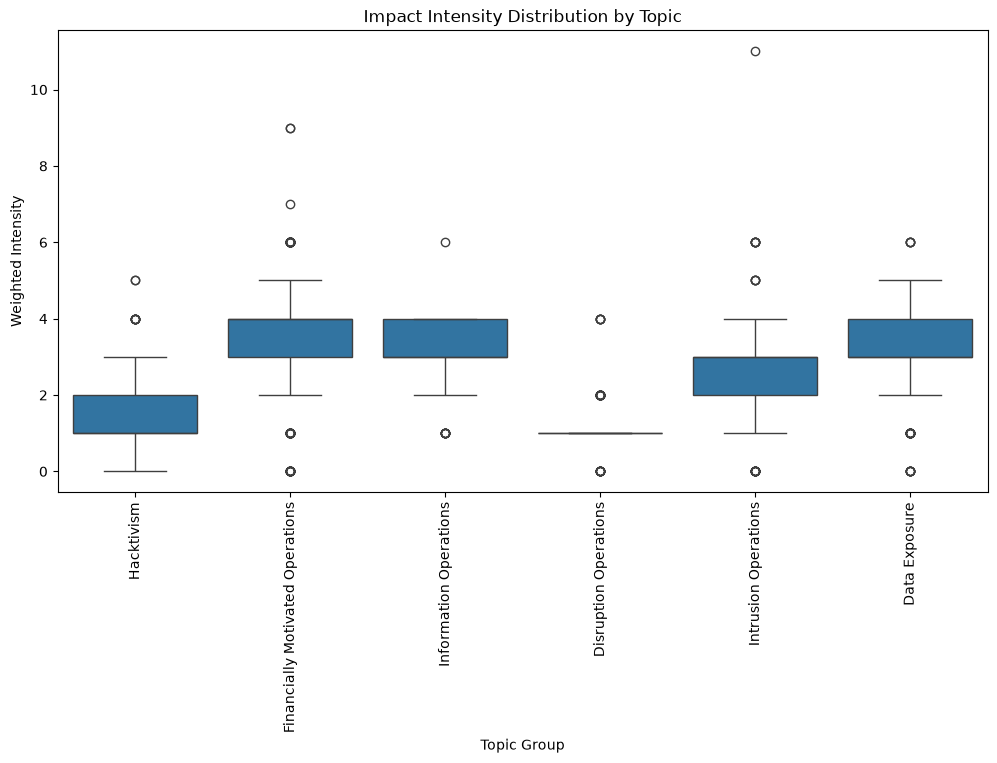

In [42]:
plt.figure(figsize=(12,6))

sns.boxplot(
    data=dyadic_data,
    x="topic_group",
    y="weighted_intensity"
)

plt.xticks(rotation=90)
plt.ylabel("Weighted Intensity")
plt.xlabel("Topic Group")
plt.title("Impact Intensity Distribution by Topic")
plt.show()

Kruskal-Wallis test for significant differences between operation types

In [43]:
# First drop duplicate incident_ids in the dataset
topic_analysis = (
    dyadic_data
    .drop_duplicates(subset=["incident_id"])
    .copy()
)

# Check sample sizes
print(
    dyadic_data.groupby("topic_group")
    .size()
    .sort_values(ascending=False)
)

# Run Kruskal-Wallis test
groups = [
    g["weighted_intensity"].dropna()
    for _, g in topic_analysis.groupby("topic_name")
]

stat, p = kruskal(*groups)

print(f"Kruskal-Wallis H-statistic: {stat:.3f}")
print(f"p-value: {p:.6f}")

alpha = 0.05

if p < alpha:
    print("Significant differences in weighted intensity across topics.")
else:
    print("No significant differences in weighted intensity across topics.")


topic_group
Intrusion Operations                823
Hacktivism                          478
Financially Motivated Operations    422
Disruption Operations               202
Data Exposure                       194
Information Operations              127
dtype: int64
Kruskal-Wallis H-statistic: 686.467
p-value: 0.000000
Significant differences in weighted intensity across topics.


In [48]:
# Dunn test
dunn = sp.posthoc_dunn(
    topic_analysis,
    val_col="weighted_intensity",
    group_col="topic_group",
    p_adjust="bonferroni"
)


# Convert Dunn matrix to long format
results = []

for i, row in enumerate(dunn.index):
    for j, col in enumerate(dunn.columns):

        # Keep upper triangle only
        if i < j:

            p = dunn.loc[row, col]

            results.append({
                "Comparison": f"{row} vs {col}",
                "p-value": p,
                "Significant": "Yes" if p < 0.05 else "No"
            })

dunn_table = pd.DataFrame(results)

dunn_table = (
    dunn_table
    .sort_values("Comparison")
    .reset_index(drop=True)
)

dunn_table["p-value"] = (
    dunn_table["p-value"]
    .apply(lambda x: "<0.001" if x < 0.001 else f"{x:.3f}")
)

print(dunn_table.to_string(index=False))

                                                Comparison p-value Significant
                    Data Exposure vs Disruption Operations  <0.001         Yes
         Data Exposure vs Financially Motivated Operations   0.172          No
                               Data Exposure vs Hacktivism  <0.001         Yes
                   Data Exposure vs Information Operations   1.000          No
                     Data Exposure vs Intrusion Operations  <0.001         Yes
 Disruption Operations vs Financially Motivated Operations  <0.001         Yes
                       Disruption Operations vs Hacktivism   0.899          No
           Disruption Operations vs Information Operations  <0.001         Yes
             Disruption Operations vs Intrusion Operations  <0.001         Yes
            Financially Motivated Operations vs Hacktivism  <0.001         Yes
Financially Motivated Operations vs Information Operations   1.000          No
  Financially Motivated Operations vs Intrusion Oper

## Key Findings
**1. Operational type is associated with severity**
- The Kruskal-Wallis test found significant variation in incident intensity between categories
- The way a cyber operation is conducted appears to be linked ot its observed intensity, with ransomware and extortion representing the most distinct category and hacktivist activities generally representing the least severe

**2. Ransomware & cyber-extortion incidents differed significantly from all other operational categories**
- This suggests that financially motivated attacks exhibit a unique intensity profile compared to other forms of cyber activity

**3. Hacktivism & Disruption Operations occupy the lower-intensity end of the spectrum**
- Both categories differed significantly from most other groups
- Website defacements, symbolic attacks, and service disruptions tend to be less severe than ransomware, espionage, or other intrusion-focused attacks

**4. Data Exposure and Intrusion Operations show similar severity levels**
- Data breaches and instrusion-based operations have comparable intensity characteristics

**5. Information Operations & Intrusion Operations also exhibit similar intensity profiles**
-  Espionage and surveillance oriented incidents appear to operate at a simliar level of severity as malware and exploitation activities

**6. Most operational categories remain distinguishable from each other**
- The majority of pairwise comparisons were significant, indicating meaningful differences in severity across cyber-operation types. 

In [ ]:
pd.crosstab(
    dyadic_data["receiver_country"],
    dyadic_data["topic_name"],
    normalize="index"
)

In [ ]:
topic_analysis.loc[
    topic_analysis["topic_group"].isna(),
    ["topic_name"]
].drop_duplicates()